In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import GridSearchCV

import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [45]:
df=pd.read_csv('adult.csv')

In [46]:
#  DATA UNDERSTANDING
print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


Column Names:
Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss  


Income Value Counts:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


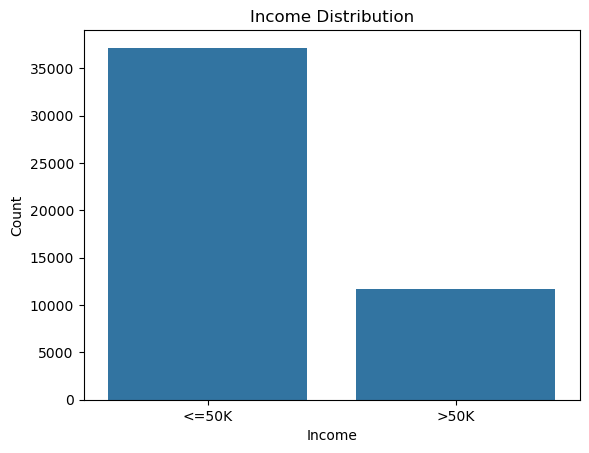

In [47]:
# CHECK TARGET VARIABLE
print("\nIncome Value Counts:")
print(df['income'].value_counts())

sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

In [48]:
#  ONE HOT ENCODING
df = pd.concat([df.drop('occupation', axis=1),
                pd.get_dummies(df['occupation']).add_prefix('occupation_')],
               axis=1)
df = pd.concat([df.drop('workclass', axis=1),
                pd.get_dummies(df['workclass']).add_prefix('workclass_')],
               axis=1)
df = df.drop('education', axis=1)
df = pd.concat([df.drop('marital-status', axis=1),
                pd.get_dummies(df['marital-status']).add_prefix('marital-status_')],
               axis=1)
df = pd.concat([df.drop('relationship', axis=1),
                pd.get_dummies(df['relationship']).add_prefix('relationship_')],
               axis=1)
df = pd.concat([df.drop('race', axis=1),
                pd.get_dummies(df['race']).add_prefix('race_')],
               axis=1)
df = pd.concat([df.drop('native-country', axis=1),
                pd.get_dummies(df['native-country']).add_prefix('native-country_')],
               axis=1)


In [49]:
df['gender']=df['gender'].apply(lambda x: 1 if x=="Male" else 0)
df['income']=df['income'].apply(lambda x: 1 if x=='>50K' else 0)

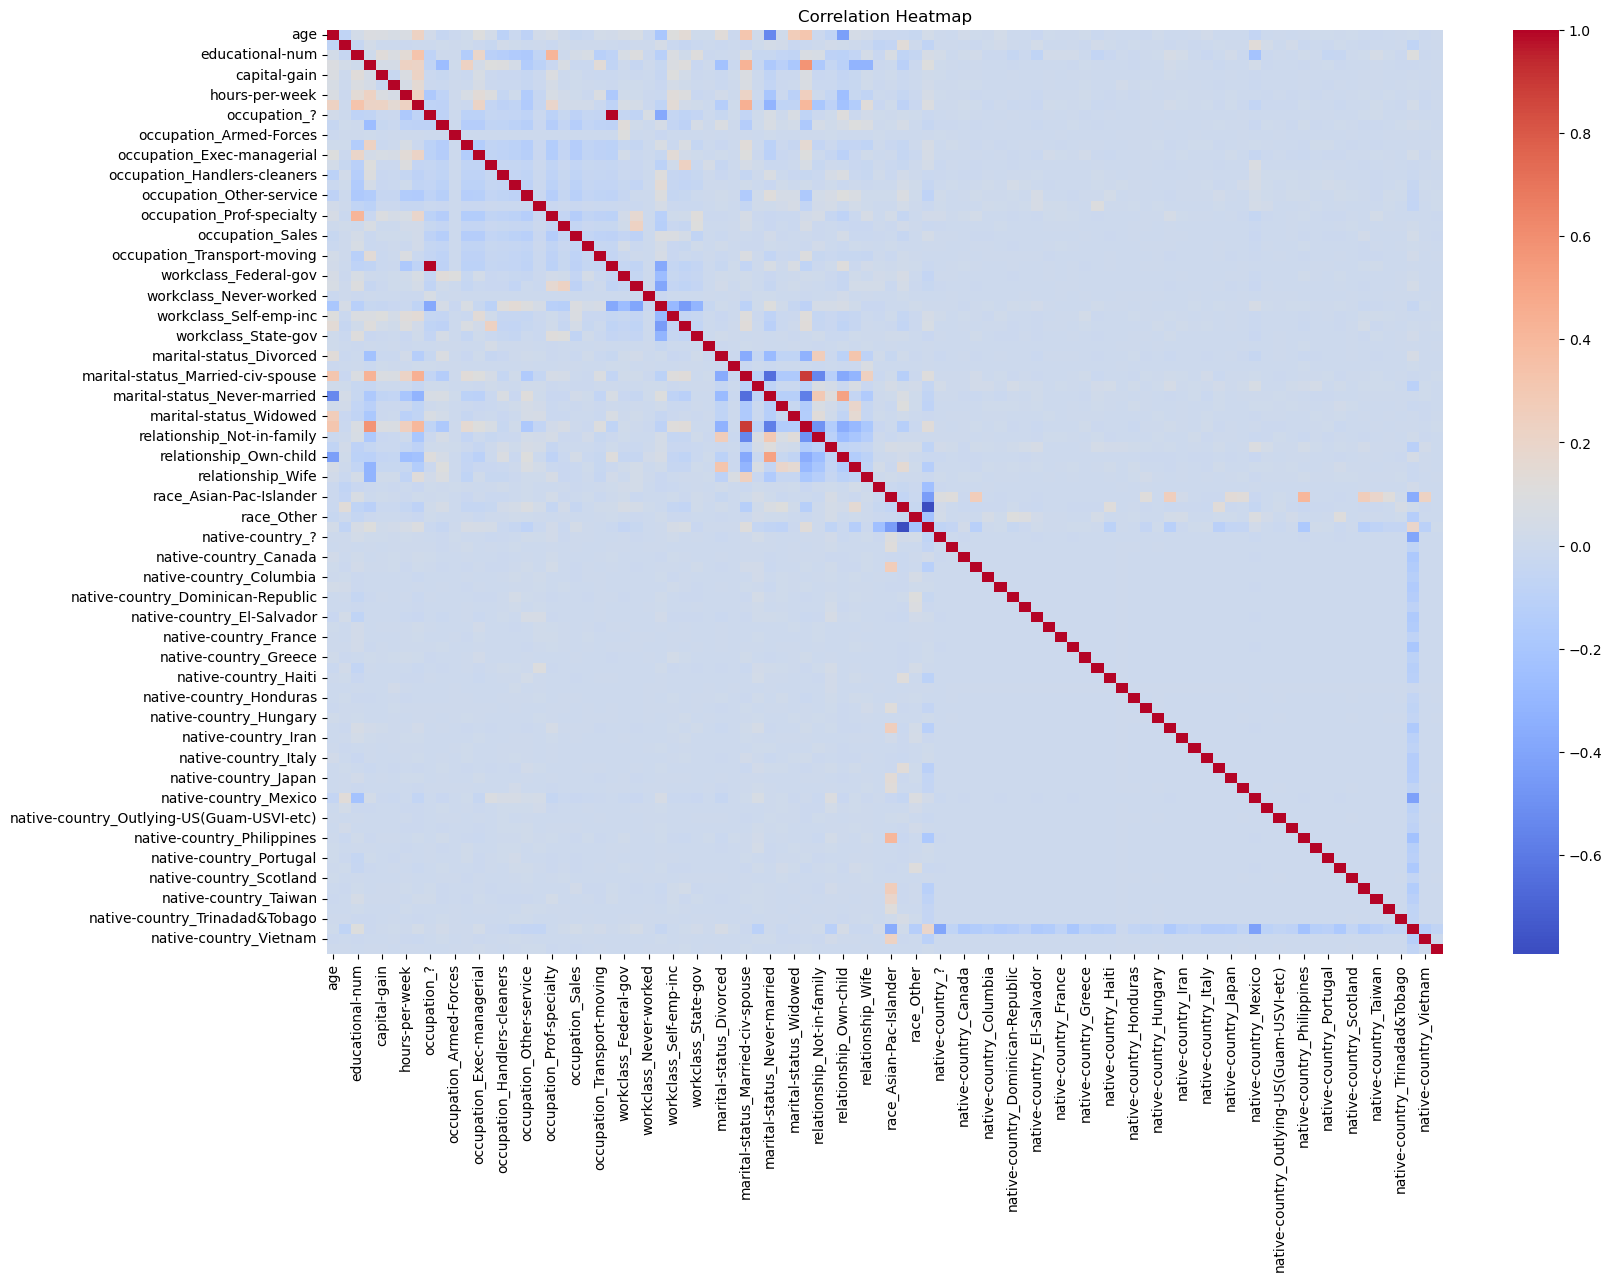

In [50]:
# CORRELATION HEATMAP
plt.figure(figsize=(18,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [51]:
#  FEATURE IMPORTANCE CHECK
correlations = df.corr()['income'].abs().sort_values(
    ascending=False
)

print("\nTop Correlated Features:")
print(correlations.head(15))


Top Correlated Features:
income                               1.000000
marital-status_Married-civ-spouse    0.445853
relationship_Husband                 0.403791
educational-num                      0.332613
marital-status_Never-married         0.318782
age                                  0.230369
hours-per-week                       0.227687
relationship_Own-child               0.225691
capital-gain                         0.223013
gender                               0.214628
occupation_Exec-managerial           0.210938
relationship_Not-in-family           0.190372
occupation_Prof-specialty            0.188793
occupation_Other-service             0.155254
capital-loss                         0.147554
Name: income, dtype: float64


In [52]:
#  SPLIT FEATURES AND TARGET
X = df.drop('income', axis=1)
y = df['income']

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (48842, 91)
Target Shape: (48842,)


In [53]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Training Data Shape: (39073, 91)
Testing Data Shape: (9769, 91)


In [54]:
#  TRAIN RANDOM FOREST MODEL
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(X_train, y_train)

print("\nModel Training Completed")



Model Training Completed


In [55]:
#  PREDICTIONS
y_pred = forest.predict(X_test)

In [56]:
#  MODEL EVALUATION
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score:
0.8617053946156208

Confusion Matrix:
[[6950  529]
 [ 822 1468]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      7479
           1       0.74      0.64      0.68      2290

    accuracy                           0.86      9769
   macro avg       0.81      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769



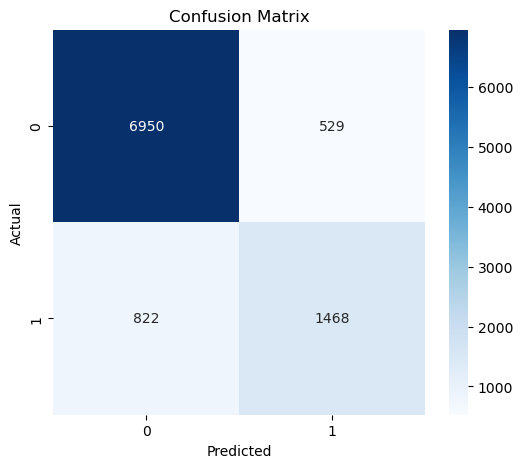

In [57]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()




Top Important Features:
                              Feature  Importance
1                              fnlwgt    0.173324
0                                 age    0.151010
2                     educational-num    0.111959
4                        capital-gain    0.094497
6                      hours-per-week    0.084813
33  marital-status_Married-civ-spouse    0.056441
38               relationship_Husband    0.054168
5                        capital-loss    0.032645
35       marital-status_Never-married    0.028511
11         occupation_Exec-managerial    0.018113


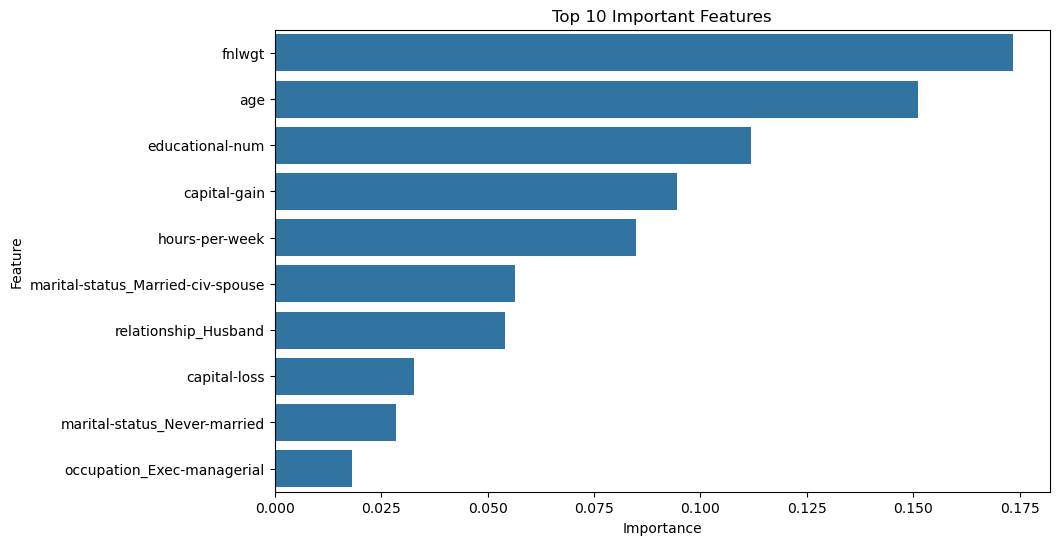

In [58]:
#  FEATURE IMPORTANCE VISUALIZATION
importance = forest.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()


In [60]:
#  HYPERPARAMETER TUNING
parameters = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parameters,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Accuracy:")
print(grid_search.best_score_)




Best Parameters:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}

Best Accuracy:
0.8626161790389237


In [61]:
#  TRAIN BEST MODEL
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

best_predictions = best_model.predict(X_test)

best_accuracy = accuracy_score(
    y_test,
    best_predictions
)

print("\nFinal Accuracy After Tuning:")
print(best_accuracy)


Final Accuracy After Tuning:
0.8715323984031119


In [62]:
#  SAVE MODEL
joblib.dump(best_model, "income_model.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully


In [63]:
#  SAVE COLUMN NAMES
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Column Names Saved Successfully")

Column Names Saved Successfully


In [64]:
# TEST WITH SAMPLE INPUT
sample_data = X.iloc[0:1]

prediction = best_model.predict(sample_data)

print("\nSample Prediction:")

if prediction[0] == 1:
    print("Predicted Income: >50K")
else:
    print("Predicted Income: <=50K")


Sample Prediction:
Predicted Income: <=50K


In [65]:
print("PROJECT COMPLETED SUCCESSFULLY")

PROJECT COMPLETED SUCCESSFULLY
